In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
sys.path.append("./src")

from utils import *

from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime.fake_provider import FakeWashingtonV2, FakeAthensV2

from matplotlib import pyplot as plt
import sys
import numpy as np
from qiskit.quantum_info import Pauli, Statevector
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.visualization import plot_gate_map
from qiskit.transpiler import CouplingMap

import pickle


sys.path.append("../../pauli_lindblad_per/")
from tomography.experiment import SparsePauliTomographyExperiment as tomography

plt.style.use("ggplot")

Initial Error: 0.10484684299231518
Exakte Energie:  -7.819890870294844
Optimierte Parameter: [-2.13354542e-05 -1.96813607e+00  1.57075369e+00]
Minimaler Fehler: 0.004204534323267825


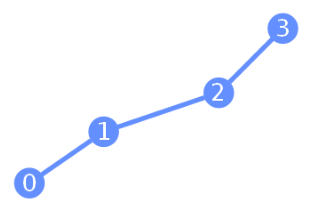

In [2]:
coupling = CouplingMap(couplinglist=[(0, 1), (1, 2), (2, 3)])
backend = GenericBackendV2(num_qubits=4, coupling_map=coupling)

num_qubits, coupling_map = get_backend_info(backend)
plot_gate_map(backend)

hx = 1
hz = 1
J= -1
H_sparse = build_sparse_hamiltonian(hx, hz, backend, J=J)

best_guess, energy_exact = find_best_initial_params(H_sparse, backend)

opt_params, min_error = optimize_energy(best_guess, H_sparse, backend, energy_exact)

expectation_values, paulis = compute_individual_expectation_values(opt_params, backend, hx, hz,J=J, num_layers=1)

print(f"Initial Error: {compute_error(best_guess, H_sparse, backend, energy_exact, num_layers=1)}")
print("Exakte Energie: ", energy_exact)
print("Optimierte Parameter:", opt_params)
print("Minimaler Fehler:", min_error)

In [ ]:
# === 1. Fehlerwahrscheinlichkeiten (Pauli-Kanal) === #

# 1-Qubit: Fehlerwahrscheinlichkeiten pro Pauli-Term (pro Qubit)
p1q = {
    0: {'X': 0.01, 'Y': 0.01, 'Z': 0.01},  # 3% Fehler
    1: {'X': 0.015, 'Y': 0.005, 'Z': 0.01},
    2: {'X': 0.005, 'Y': 0.015, 'Z': 0.005},
    3: {'X': 0.01, 'Y': 0.01, 'Z': 0.02},
}

# 2-Qubit CX-Pauli-Fehler
p2q_cx = {
    (0, 1): {'IX': 0.01, 'XI': 0.01, 'ZZ': 0.015},  # 3.5%
    (1, 2): {'XX': 0.015, 'YY': 0.005},             # 2%
    (2, 3): {'IZ': 0.01, 'ZI': 0.01},               # 2%
}


# === 2. Hilfsfunktionen zum Erzeugen von PauliError === #

def make_1q_pauli_error(pdict):
    pX = pdict.get('X', 0.0)
    pY = pdict.get('Y', 0.0)
    pZ = pdict.get('Z', 0.0)
    pI = 1.0 - (pX + pY + pZ)
    if pI < -1e-12:
        raise ValueError(f"Sum > 1: {pX+pY+pZ}")
    pI = max(pI, 0.0)
    terms = [(p, pdict[p]) for p in ['X','Y','Z'] if pdict.get(p, 0.0)]
    terms.append(('I', pI))
    return pauli_error(terms)

def make_2q_pauli_error(pdict):
    total = sum(pdict.values())
    pI = 1.0 - total
    if pI < -1e-12:
        raise ValueError(f"Sum > 1: {total}")
    pI = max(pI, 0.0)
    terms = [(label, p) for label, p in pdict.items()]
    terms.append(('II', pI))
    return pauli_error(terms)


# === 3. NoiseModel erstellen === #

#backend = FakeWashingtonV2()
noise_model = NoiseModel()

# 1-Qubit Fehler: auf alle physikalischen Basisgates anwenden
# Hole die Basisgates vom Backend
#basis_gates = backend.configuration().basis_gates
#oneq_gates = [g for g in basis_gates if g in ['id','x','sx','rz','ry','rx','u1','u2','u3']]  # anpassen je nach Bedarf

for q in [0,1,2,3]:
    error = make_1q_pauli_error(p1q[q])
    noise_model.add_quantum_error(error, oneq_gates, [q])

# 2-Qubit Fehler: auf die CX-Gates (nur die angegebenen)
for (ctrl, tgt), paulis in p2q_cx.items():
    error = make_2q_pauli_error(paulis)
    noise_model.add_quantum_error(error, ['cx'], [ctrl, tgt])
    
simulator = AerSimulator.from_backend(backend)


AttributeError: 'GenericBackendV2' object has no attribute 'configuration'

In [ ]:
#backend = FakeWashingtonV2()
#plot_gate_map(backend)
"""coupling_list = backend.configuration().coupling_map
print("Coupling Map:", coupling_list)"""

#noise_model = NoiseModel.from_backend(backend)
simulator = AerSimulator.from_backend(backend)

In [ ]:
inst_map = [0,1,2,3]
qc = build_hva_layers(opt_params, backend, qubit_indices=inst_map, num_layers=1)

qc.draw('mpl')

In [ ]:
experiment = tomography(
    circuits = [qc], #list of circuits from which to get the layers requiring tomography
    inst_map = inst_map, #which physical qubits on the processor to map the qubits in the circuit
    backend = backend, #quantum backend
    used_qubits= inst_map
    )

experiment.generate(
    samples = 100, #Number of samples to take from the fidelity pair measurements
    single_samples = 250, #samples to take from the pair-breaking measurements
    depths = [2,4,16,32,64] #values of 2n to make the pair measurements. Numbers must be even and non-zero
    )

shots = 1024
def executor(circuits):
    return backend.run(circuits, shots = shots, noise_model=noise_model).result().get_counts()

#run the experiment
experiment.run(executor)
noisedataframe = experiment.analyze()

In [ ]:
layer = experiment.analysis.get_layer_data(0)
layer.plot_infidelitites(plot_style = 2)

In [ ]:
layer.plot_coeffs(plot_style = 2 )